In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import duckdb

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import joblib

In [2]:
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
FIGURES_DIR = Path("../reports/figures")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

top200_path = PROCESSED_DIR / "charts_top200_clean.parquet"
viral50_path = PROCESSED_DIR / "charts_viral50_clean.parquet"

top200_path, viral50_path

(PosixPath('../data/processed/charts_top200_clean.parquet'),
 PosixPath('../data/processed/charts_viral50_clean.parquet'))

In [3]:
con = duckdb.connect()

In [4]:
breakout_df = con.execute(f"""
WITH viral_track_week AS (
    SELECT
        region,
        url,
        ANY_VALUE(title) AS title,
        ANY_VALUE(artist) AS artist,
        CAST(date_trunc('week', date) AS DATE) AS week,
        MIN(rank) AS best_viral_rank,
        AVG(rank) AS avg_viral_rank,
        COUNT(*) AS viral_days_on_chart,
        SUM(CASE WHEN trend = 'MOVE_UP' THEN 1 ELSE 0 END) AS viral_move_up_count,
        SUM(CASE WHEN trend = 'MOVE_DOWN' THEN 1 ELSE 0 END) AS viral_move_down_count,
        SUM(CASE WHEN trend = 'NEW_ENTRY' THEN 1 ELSE 0 END) AS viral_new_entry_count,
        SUM(CASE WHEN trend = 'SAME_POSITION' THEN 1 ELSE 0 END) AS viral_same_position_count
    FROM read_parquet('{viral50_path}')
    WHERE region != 'Global'
    GROUP BY region, url, CAST(date_trunc('week', date) AS DATE)
),

top200_track_week AS (
    SELECT
        region,
        url,
        CAST(date_trunc('week', date) AS DATE) AS week,
        MIN(rank) AS best_top200_rank,
        SUM(streams) AS top200_weekly_streams
    FROM read_parquet('{top200_path}')
    WHERE region != 'Global'
    GROUP BY region, url, CAST(date_trunc('week', date) AS DATE)
),

max_week AS (
    SELECT MAX(week) AS max_top200_week
    FROM top200_track_week
),

labeled AS (
    SELECT
        v.*,

        CASE
            WHEN EXISTS (
                SELECT 1
                FROM top200_track_week t
                WHERE t.region = v.region
                  AND t.url = v.url
                  AND t.week = v.week
            )
            THEN 1 ELSE 0
        END AS already_top200_same_week,

        CASE
            WHEN EXISTS (
                SELECT 1
                FROM top200_track_week t
                WHERE t.region = v.region
                  AND t.url = v.url
                  AND t.week > v.week
                  AND t.week <= v.week + INTERVAL '14 days'
            )
            THEN 1 ELSE 0
        END AS breakout_14d

    FROM viral_track_week v
    CROSS JOIN max_week m
    WHERE v.week <= m.max_top200_week - INTERVAL '14 days'
)

SELECT *
FROM labeled
WHERE already_top200_same_week = 0
ORDER BY region, week
""").df()

print(breakout_df.shape)
breakout_df.head()

(772853, 14)


,region,url,title,artist,week,best_viral_rank,avg_viral_rank,viral_days_on_chart,viral_move_up_count,viral_move_down_count,viral_new_entry_count,viral_same_position_count,already_top200_same_week,breakout_14d
0,Andorra,https://open.spotify.com/track/5QzgO7zpLouZswU...,A mi manera,Raphael,2016-12-26,23,23.0,1,1.0,0.0,0.0,0.0,0,0
1,Andorra,https://open.spotify.com/track/165188K7zQggqTc...,All I Want Is You,U2,2016-12-26,17,17.0,1,1.0,0.0,0.0,0.0,0,0
2,Andorra,https://open.spotify.com/track/0lYBx37mRl0dbP7...,A Mi Manera - Tema Remasterizado,Vicente Fernández,2016-12-26,25,25.0,1,0.0,1.0,0.0,0.0,0,0
3,Andorra,https://open.spotify.com/track/4kAJawkLZj4Q7N5...,With Or Without You - Remastered,U2,2016-12-26,3,3.0,1,1.0,0.0,0.0,0.0,0,0
4,Andorra,https://open.spotify.com/track/2CZWUmcG9swKChE...,8 Days of Christmas,Destiny's Child,2016-12-26,5,5.0,1,0.0,0.0,0.0,1.0,0,0


In [7]:
breakout_df["breakout_14d"].value_counts()
breakout_rate = breakout_df["breakout_14d"].mean()
print("Breakout rate:", round(breakout_rate, 4))

Breakout rate: 0.0341


In [8]:
breakout_df["viral_move_up_share"] = (
    breakout_df["viral_move_up_count"] / breakout_df["viral_days_on_chart"]
)

breakout_df["viral_move_down_share"] = (
    breakout_df["viral_move_down_count"] / breakout_df["viral_days_on_chart"]
)

breakout_df["viral_new_entry_share"] = (
    breakout_df["viral_new_entry_count"] / breakout_df["viral_days_on_chart"]
)

breakout_df["viral_same_position_share"] = (
    breakout_df["viral_same_position_count"] / breakout_df["viral_days_on_chart"]
)

breakout_df.head()

,region,url,title,artist,week,best_viral_rank,avg_viral_rank,viral_days_on_chart,viral_move_up_count,viral_move_down_count,viral_new_entry_count,viral_same_position_count,already_top200_same_week,breakout_14d,viral_move_up_share,viral_move_down_share,viral_new_entry_share,viral_same_position_share
0,Andorra,https://open.spotify.com/track/5QzgO7zpLouZswU...,A mi manera,Raphael,2016-12-26,23,23.0,1,1.0,0.0,0.0,0.0,0,0,1.0,0.0,0.0,0.0
1,Andorra,https://open.spotify.com/track/165188K7zQggqTc...,All I Want Is You,U2,2016-12-26,17,17.0,1,1.0,0.0,0.0,0.0,0,0,1.0,0.0,0.0,0.0
2,Andorra,https://open.spotify.com/track/0lYBx37mRl0dbP7...,A Mi Manera - Tema Remasterizado,Vicente Fernández,2016-12-26,25,25.0,1,0.0,1.0,0.0,0.0,0,0,0.0,1.0,0.0,0.0
3,Andorra,https://open.spotify.com/track/4kAJawkLZj4Q7N5...,With Or Without You - Remastered,U2,2016-12-26,3,3.0,1,1.0,0.0,0.0,0.0,0,0,1.0,0.0,0.0,0.0
4,Andorra,https://open.spotify.com/track/2CZWUmcG9swKChE...,8 Days of Christmas,Destiny's Child,2016-12-26,5,5.0,1,0.0,0.0,0.0,1.0,0,0,0.0,0.0,0.0,1.0


In [9]:
breakout_dataset_path = PROCESSED_DIR / "breakout_modeling_dataset.csv"

breakout_df.to_csv(breakout_dataset_path, index=False)

print("Saved breakout dataset to:", breakout_dataset_path)
print(breakout_df.shape)

Saved breakout dataset to: ../data/processed/breakout_modeling_dataset.csv
(772853, 18)


In [10]:
breakout_summary = breakout_df.groupby("breakout_14d").agg({
    "best_viral_rank": "mean",
    "avg_viral_rank": "mean",
    "viral_days_on_chart": "mean",
    "viral_move_up_share": "mean",
    "viral_move_down_share": "mean",
    "viral_new_entry_share": "mean",
    "viral_same_position_share": "mean"
})

breakout_summary

,best_viral_rank,avg_viral_rank,viral_days_on_chart,viral_move_up_share,viral_move_down_share,viral_new_entry_share,viral_same_position_share
breakout_14d,,,,,,,
0,27.244075,31.377388,4.333051,0.304486,0.339327,0.254517,0.101670
1,21.356891,25.973629,5.053564,0.377406,0.274910,0.207857,0.139826


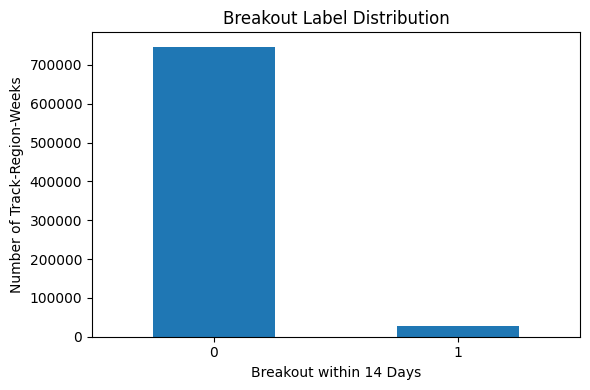

In [11]:
plt.figure(figsize=(6, 4))
breakout_df["breakout_14d"].value_counts().sort_index().plot(kind="bar")
plt.title("Breakout Label Distribution")
plt.xlabel("Breakout within 14 Days")
plt.ylabel("Number of Track-Region-Weeks")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "breakout_label_distribution.png", dpi=300)
plt.show()

In [12]:
feature_cols = [
    "region",
    "best_viral_rank",
    "avg_viral_rank",
    "viral_days_on_chart",
    "viral_move_up_count",
    "viral_move_down_count",
    "viral_new_entry_count",
    "viral_same_position_count",
    "viral_move_up_share",
    "viral_move_down_share",
    "viral_new_entry_share",
    "viral_same_position_share"
]

target_col = "breakout_14d"

X = breakout_df[feature_cols]
y = breakout_df[target_col]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (772853, 12)
Target: (772853,)


In [13]:
breakout_df["week"] = pd.to_datetime(breakout_df["week"])

unique_weeks = sorted(breakout_df["week"].unique())

split_index = int(len(unique_weeks) * 0.8)
split_week = unique_weeks[split_index]

print("Split week:", split_week)

Split week: 2020-12-21 00:00:00


In [14]:
train_df = breakout_df[breakout_df["week"] < split_week].copy()
test_df = breakout_df[breakout_df["week"] >= split_week].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train breakout rate:", round(y_train.mean(), 4))
print("Test breakout rate:", round(y_test.mean(), 4))

Train shape: (618761, 12)
Test shape: (154092, 12)
Train breakout rate: 0.0331
Test breakout rate: 0.0384


In [15]:
numeric_features = [
    "best_viral_rank",
    "avg_viral_rank",
    "viral_days_on_chart",
    "viral_move_up_count",
    "viral_move_down_count",
    "viral_new_entry_count",
    "viral_same_position_count",
    "viral_move_up_share",
    "viral_move_down_share",
    "viral_new_entry_share",
    "viral_same_position_share"
]

categorical_features = ["region"]

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [16]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled),
            ("model", LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            ))
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("model", RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]
    )
}

In [17]:
def evaluate_classifier(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_pred_proba)
    }

In [18]:
breakout_results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)

    model_results = evaluate_classifier(model_name, model, X_test, y_test)
    breakout_results.append(model_results)

breakout_results_df = pd.DataFrame(breakout_results)
breakout_results_df

Training Logistic Regression...
Training Random Forest...


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.580737,0.059975,0.676819,0.110185,0.677047
1,Random Forest,0.597020,0.059367,0.640440,0.108661,0.677367


In [19]:
for model_name, model in models.items():
    print("=" * 60)
    print(model_name)
    print("=" * 60)

    y_pred = model.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

Logistic Regression
Confusion Matrix:
[[85487 62695]
 [ 1910  4000]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.58      0.73    148182
           1       0.06      0.68      0.11      5910

    accuracy                           0.58    154092
   macro avg       0.52      0.63      0.42    154092
weighted avg       0.94      0.58      0.70    154092

Random Forest
Confusion Matrix:
[[88211 59971]
 [ 2125  3785]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.60      0.74    148182
           1       0.06      0.64      0.11      5910

    accuracy                           0.60    154092
   macro avg       0.52      0.62      0.42    154092
weighted avg       0.94      0.60      0.72    154092



In [20]:
best_breakout_model_name = "Logistic Regression"
best_breakout_model = models[best_breakout_model_name]

In [21]:
rf_breakout_model = models["Random Forest"]

preprocessor = rf_breakout_model.named_steps["preprocessor"]
trained_rf = rf_breakout_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()

breakout_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_rf.feature_importances_
}).sort_values("importance", ascending=False)

breakout_importance.head(20)

,feature,importance
0,num__best_viral_rank,0.164957
2,num__viral_days_on_chart,0.136680
1,num__avg_viral_rank,0.135204
11,cat__region_Andorra,0.094567
3,num__viral_move_up_count,0.088788
7,num__viral_move_up_share,0.080021
8,num__viral_move_down_share,0.066914
10,num__viral_same_position_share,0.041757
9,num__viral_new_entry_share,0.033580
6,num__viral_same_position_count,0.032099


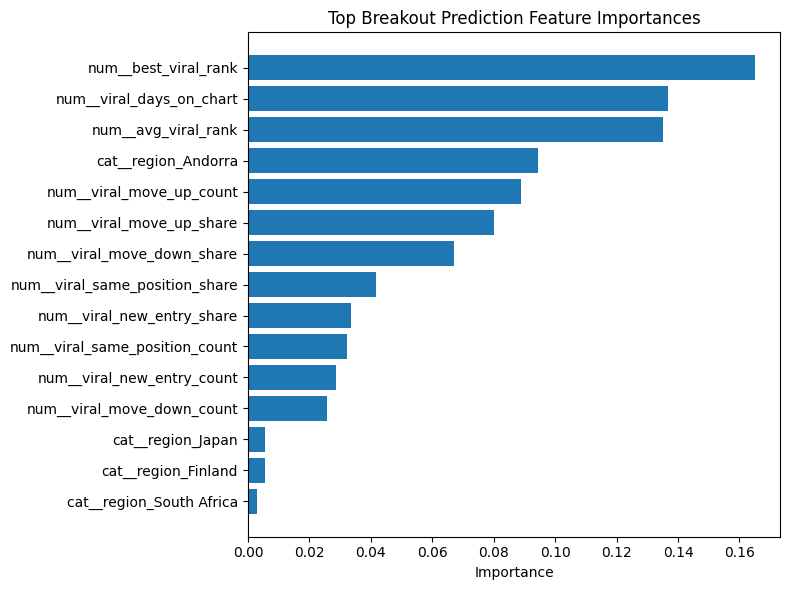

In [22]:
top_breakout_features = breakout_importance.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_breakout_features["feature"], top_breakout_features["importance"])
plt.title("Top Breakout Prediction Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "breakout_feature_importance.png", dpi=300)
plt.show()

In [23]:
breakout_model_path = MODELS_DIR / "best_breakout_model.pkl"

joblib.dump({
    "model": best_breakout_model,
    "feature_cols": feature_cols,
    "target_definition": "Viral 50 track enters same-region Top 200 within next 14 days"
}, breakout_model_path)

print("Saved breakout model to:", breakout_model_path)

Saved breakout model to: ../models/best_breakout_model.pkl


In [24]:
latest_week = breakout_df["week"].max()
latest_candidates = breakout_df[breakout_df["week"] == latest_week].copy()

latest_X = latest_candidates[feature_cols]

latest_candidates["breakout_probability"] = best_breakout_model.predict_proba(latest_X)[:, 1]

recommendations = (
    latest_candidates[
        [
            "region",
            "week",
            "title",
            "artist",
            "url",
            "best_viral_rank",
            "avg_viral_rank",
            "viral_days_on_chart",
            "breakout_probability"
        ]
    ]
    .sort_values("breakout_probability", ascending=False)
)

recommendations.head(20)

,region,week,title,artist,url,best_viral_rank,avg_viral_rank,viral_days_on_chart,breakout_probability
277579,Greece,2021-12-13,DTB,Merczz,https://open.spotify.com/track/6BoXckigjvnIAZV...,7,11.714286,7,0.859307
277568,Greece,2021-12-13,Swimming Pool,Marie Madeleine,https://open.spotify.com/track/3BMqVk2NJbH4fxf...,3,5.142857,7,0.858579
277600,Greece,2021-12-13,MIDDLE OF THE NIGHT,Elley Duhé,https://open.spotify.com/track/58HvfVOeJY7lUuC...,1,1.000000,7,0.852780
542126,Panama,2021-12-13,abcdefu,GAYLE,https://open.spotify.com/track/4fouWK6XVHhzl78...,1,1.000000,7,0.850339
277561,Greece,2021-12-13,abcdefu,GAYLE,https://open.spotify.com/track/4fouWK6XVHhzl78...,2,2.000000,7,0.850245
649416,South Africa,2021-12-13,Super Max!,Pitstop Boys,https://open.spotify.com/track/4gqOzJPGNCvEnS1...,1,1.714286,7,0.845770
605203,Romania,2021-12-13,It's Called: Freefall,Rainbow Kitten Surprise,https://open.spotify.com/track/474uVhyGgK5MtY9...,5,11.428571,7,0.845304
640555,Slovakia,2021-12-13,Pope Is a Rockstar,SALES,https://open.spotify.com/track/0So2sgVa8aJiARP...,5,9.000000,7,0.844921
723622,Ukraine,2021-12-13,Первый раз,Krasnaya Plesen,https://open.spotify.com/track/4bxaIFqvSpqqAHx...,14,20.285714,7,0.844371
428911,Lithuania,2021-12-13,Pope Is a Rockstar,SALES,https://open.spotify.com/track/0So2sgVa8aJiARP...,3,4.000000,7,0.843579


In [25]:
breakout_recommendations_path = PROCESSED_DIR / "latest_breakout_recommendations.csv"

recommendations.to_csv(breakout_recommendations_path, index=False)

print("Saved breakout recommendations to:", breakout_recommendations_path)

Saved breakout recommendations to: ../data/processed/latest_breakout_recommendations.csv


## Breakout Model Selection

Logistic Regression was selected as the final breakout prediction model.

Although Random Forest achieved a slightly higher ROC-AUC score, the difference was extremely small. Logistic Regression achieved better recall and F1 score, which are more important for this use case.

The goal of the breakout model is not to perfectly classify every track as breakout or non-breakout. Instead, the goal is to identify and rank promising Viral 50 tracks that may enter the Top 200 chart within the next 14 days.

The model has low precision, which means many predicted breakout candidates may not actually become breakouts. However, it has relatively strong recall, meaning it captures a large share of actual breakout tracks. This makes it more useful as an early-warning recommendation system than as a strict binary classifier.

For the portfolio project, the breakout model should be presented as a ranking and prioritization tool for regional content promotion rather than a perfect yes/no prediction system.